# XGBoost for Cancer Prediction

In this notebook, we use **XGBoost** (Extreme Gradient Boosting), one of the most powerful and widely used algorithms in Machine Learning competitions and real-world applications, to predict whether a breast tumor is **benign** or **malignant** based on cell characteristics from the **Breast Cancer Wisconsin dataset**. XGBoost is an ensemble method built on gradient-boosted decision trees — it builds trees sequentially, where each new tree tries to correct the errors made by the previous ones, resulting in a highly accurate and efficient model. Before training, we'll explore the data to understand its structure and class balance. After training, we'll evaluate the model thoroughly using a Confusion Matrix, ROC/Precision-Recall curves, and k-Fold Cross Validation.

## Importing the libraries

We import:
- **numpy**: for numerical operations and array handling.
- **matplotlib.pyplot**: for visualizations.
- **seaborn**: for more polished statistical visualizations (heatmaps, distribution plots).
- **pandas**: for loading and exploring the dataset.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Importing the dataset

The dataset used is `Data.csv`, based on the **Breast Cancer Wisconsin (Original)** dataset. It contains 683 rows, each representing a tumor sample described by 9 cell characteristics (e.g. Clump Thickness, Uniformity of Cell Size/Shape, Marginal Adhesion, Bare Nuclei, etc.), plus a `Class` column indicating the diagnosis:
- **2** → Benign (non-cancerous)
- **4** → Malignant (cancerous)

We drop the first column (`Sample code number`), since it's just a patient ID and carries no predictive information.

- `X`: all feature columns (excluding the ID column and the target).
- `y`: the `Class` column (our target).

In [12]:
dataset = pd.read_csv('Data.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

## Exploratory Data Analysis (EDA)

Before training any model, it's important to understand the data we're working with. We use:
- `dataset.info()`: shows the number of rows, column names, data types, and whether any column has missing values based on non-null counts.
- `dataset.describe()`: shows summary statistics (mean, standard deviation, min, max, quartiles) for each numeric column, which helps us spot unusual ranges or outliers.

In [13]:
print(dataset.info())
print("\nSummary statistics:")
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Sample code number           683 non-null    int64
 1   Clump Thickness              683 non-null    int64
 2   Uniformity of Cell Size      683 non-null    int64
 3   Uniformity of Cell Shape     683 non-null    int64
 4   Marginal Adhesion            683 non-null    int64
 5   Single Epithelial Cell Size  683 non-null    int64
 6   Bare Nuclei                  683 non-null    int64
 7   Bland Chromatin              683 non-null    int64
 8   Normal Nucleoli              683 non-null    int64
 9   Mitoses                      683 non-null    int64
 10  Class                        683 non-null    int64
dtypes: int64(11)
memory usage: 58.8 KB
None

Summary statistics:


,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.830000e+02,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,1.076720e+06,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,6.206440e+05,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,6.337500e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.776170e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171795e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238705e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


## Class Distribution

Before training a classifier, it's important to check how balanced the target classes are. If one class (e.g. Benign) heavily outnumbers the other (Malignant), the model could achieve high accuracy just by favoring the majority class, while still failing to detect the minority class — which would be dangerous in a medical context. Here we visualize the distribution of Benign (2) vs Malignant (4) cases.

/tmp/ipykernel_693/3352764986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=['dodgerblue', 'salmon'])


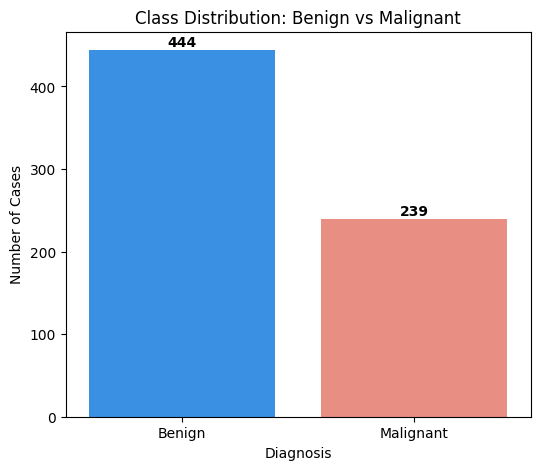

Class
Benign       444
Malignant    239
Name: count, dtype: int64

Class proportions:
Class
Benign       65.01 %
Malignant    34.99 %
Name: count, dtype: object


In [14]:
plt.figure(figsize=(6, 5))
class_counts = dataset['Class'].value_counts().rename({2: 'Benign', 4: 'Malignant'})
sns.barplot(x=class_counts.index, y=class_counts.values, palette=['dodgerblue', 'salmon'])
plt.title('Class Distribution: Benign vs Malignant')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Cases')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

print(class_counts)
print("\nClass proportions:")
print((class_counts / class_counts.sum() * 100).round(2).astype(str) + ' %')

## Correlation Heatmap

A **Correlation Heatmap** shows how strongly each pair of features (and the target) are linearly related to each other. This helps us:
- Identify which features are most correlated with the `Class` (diagnosis), giving an early hint of which ones might be the strongest predictors.
- Spot features that are highly correlated with each other (multicollinearity), which can sometimes affect model interpretability, though tree-based models like XGBoost are generally robust to this.

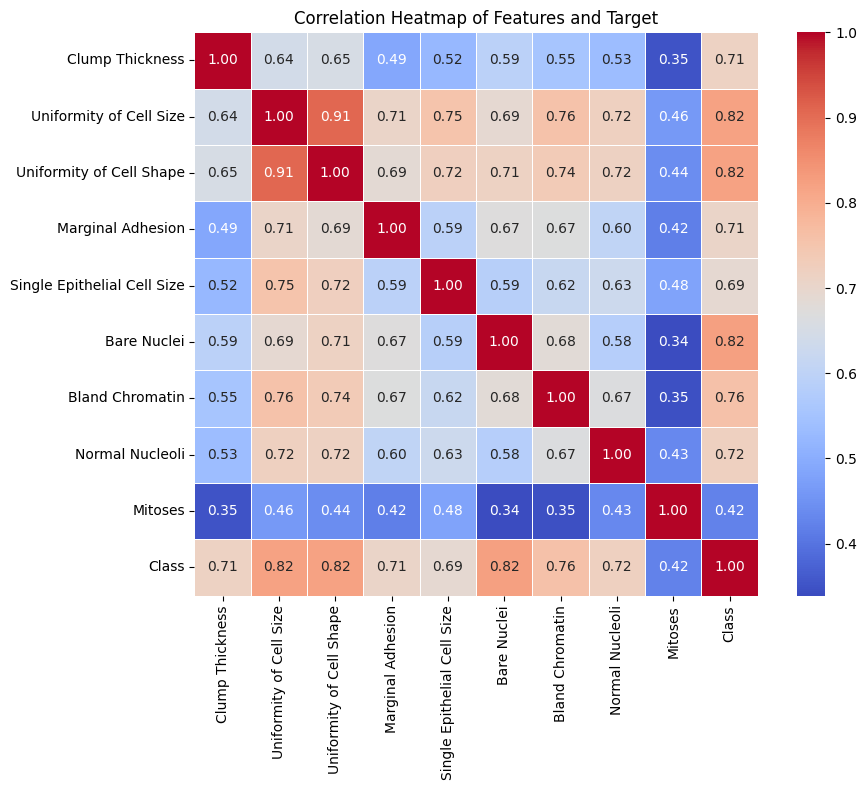

In [15]:
plt.figure(figsize=(10, 8))
correlation_matrix = dataset.iloc[:, 1:].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Features and Target')
plt.tight_layout()
plt.show()

## Checking for missing or inconsistent values

Real-world medical datasets often contain missing or malformed entries. In this dataset, the `Bare Nuclei` column is known to sometimes contain missing values marked as `'?'`. Before training any model, it's good practice to check for this and handle it, otherwise XGBoost will throw an error when trying to convert the data to numeric type.

In [16]:
# Check for any missing/placeholder values across all columns
print(dataset.isin(['?']).sum())

# If '?' values exist, replace them with NaN and drop the affected rows
dataset = dataset.replace('?', np.nan)
dataset = dataset.dropna()

# Re-extract X and y after cleaning
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values
print("Dataset shape after cleaning:", dataset.shape)

Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64
Dataset shape after cleaning: (683, 11)


## Encoding the target variable

Our target column `Class` currently has values **2** and **4**. Modern versions of XGBoost require the target labels to be encoded as consecutive integers starting from **0** (i.e. 0, 1, 2, ...) rather than arbitrary values. We use `LabelEncoder` to map:
- 2 → 0 (Benign)
- 4 → 1 (Malignant)

This step is essential — without it, newer versions of XGBoost will raise an error during training.

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

## Splitting the dataset into the Training set and Test set

We split the data into:
- **Training set (80%)**: used to train the XGBoost model and later to run k-Fold Cross Validation.
- **Test set (20%)**: kept aside to evaluate the final model on data it has never seen.

`random_state = 0` ensures the split is reproducible.

Note: unlike SVM, tree-based models like XGBoost don't require Feature Scaling — they split data based on threshold values per feature, so the scale of the features doesn't affect the model's ability to learn.

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Training XGBoost on the Training set

We train an **XGBClassifier** with its default hyperparameters. XGBoost builds an ensemble of decision trees sequentially — each tree focuses on correcting the mistakes of the previous trees (this is the "boosting" part), using gradient descent to minimize the prediction error. This makes it one of the most accurate and efficient algorithms for structured/tabular data like this medical dataset.

In [19]:
from xgboost import XGBClassifier
classifier = XGBClassifier()
classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

## Making the Confusion Matrix

We evaluate the trained model on the Test set by comparing its predictions (`y_pred`) against the true labels (`y_test`).

The **Confusion Matrix** shows:
- True Negatives / True Positives: correctly predicted Benign / Malignant cases.
- False Positives / False Negatives: misclassified cases.

In a medical context like cancer prediction, **False Negatives** (predicting Benign when the tumor is actually Malignant) are especially critical to minimize, since they represent missed diagnoses. The **Accuracy Score** gives us the overall percentage of correct predictions.

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[85  2]
 [ 2 48]]


0.9708029197080292

## Confusion Matrix as a Heatmap

The raw Confusion Matrix printed as numbers can be hard to read quickly. Visualizing it as a **heatmap** makes it much easier to interpret at a glance — the diagonal cells (top-left to bottom-right) represent correct predictions, while the off-diagonal cells represent errors.

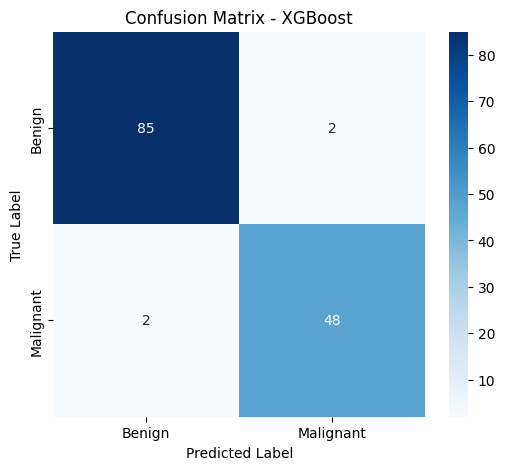

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Detailed Classification Report

Accuracy alone doesn't always tell the full story, especially in medical prediction problems where classes may be imbalanced. The `classification_report` gives us additional metrics per class:
- **Precision**: out of all cases predicted as Malignant, how many actually were?
- **Recall**: out of all actual Malignant cases, how many did the model correctly catch? (Very important in medical diagnosis.)
- **F1-score**: the harmonic mean of Precision and Recall, giving a balanced view of performance.

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98        87
   Malignant       0.96      0.96      0.96        50

    accuracy                           0.97       137
   macro avg       0.97      0.97      0.97       137
weighted avg       0.97      0.97      0.97       137



## ROC Curve & AUC Score

The **ROC Curve** (Receiver Operating Characteristic) shows the trade-off between the True Positive Rate (Recall) and the False Positive Rate as we vary the decision threshold, instead of using a single fixed threshold of 0.5. The **AUC** (Area Under the Curve) summarizes this in a single number between 0 and 1 — the closer to 1, the better the model is at distinguishing between Benign and Malignant cases across all thresholds. This is especially valuable in medical applications, where we may want to adjust the threshold to prioritize catching more Malignant cases (higher Recall) even at the cost of more false alarms.

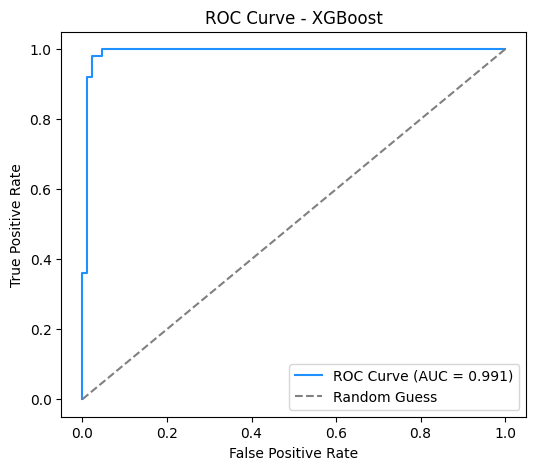

AUC Score: 0.9913


In [23]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = classifier.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='dodgerblue', label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

print("AUC Score: {:.4f}".format(auc_score))

## Precision-Recall Curve

When classes are imbalanced (as is common in medical datasets, where Benign cases often outnumber Malignant ones), the **Precision-Recall Curve** gives a more informative picture than the ROC Curve. It shows the trade-off between Precision and Recall across different thresholds, helping us choose a threshold that balances catching true Malignant cases (Recall) against minimizing false alarms (Precision).

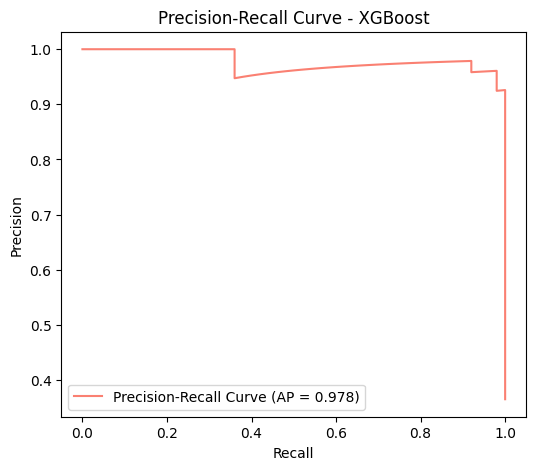

Average Precision Score: 0.9783


In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='salmon', label=f'Precision-Recall Curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend()
plt.show()

print("Average Precision Score: {:.4f}".format(avg_precision))

## Applying k-Fold Cross Validation

To get a more reliable estimate of the model's performance (rather than relying on a single Test set result), we apply **k-Fold Cross Validation**. This splits the **Training set** into `cv = 10` folds, trains and evaluates the model 10 times (each time holding out a different fold for testing), and returns 10 accuracy scores.

From these, we calculate:
- **Mean Accuracy**: a more trustworthy estimate of true model performance.
- **Standard Deviation**: shows how stable/consistent the model's performance is across different subsets of data.

In [25]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 96.71 %
Standard Deviation: 1.96 %


## Feature Importance

One of the advantages of tree-based models like XGBoost is that they naturally provide a measure of **Feature Importance** — how much each feature contributed to the model's decisions across all the trees. This helps us understand which cell characteristics are most predictive of malignancy, which can be valuable for medical interpretability.

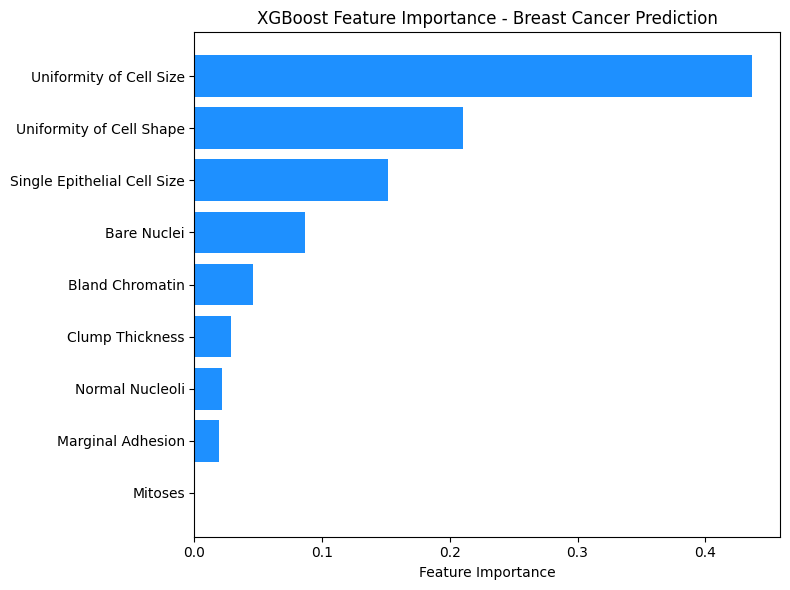

In [26]:
feature_names = dataset.columns[1:-1]
importances = classifier.feature_importances_

# Sort features by importance for a cleaner plot
sorted_idx = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importances)), importances[sorted_idx], color='dodgerblue')
plt.yticks(range(len(importances)), feature_names[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance - Breast Cancer Prediction')
plt.tight_layout()
plt.show()

## Conclusion

In this notebook, we used **XGBoost** to predict breast cancer diagnosis (Benign vs Malignant) based on cell characteristics. We began with Exploratory Data Analysis to understand the data's structure, class balance, and feature correlations. After cleaning the data and properly encoding the target labels, we trained the model and evaluated it thoroughly — using a Confusion Matrix, Classification Report, ROC Curve, and Precision-Recall Curve — before validating its performance rigorously with k-Fold Cross Validation. We also inspected Feature Importance to understand which cell characteristics most influence the model's predictions. The result is a highly accurate, well-evaluated, and interpretable model — well suited for a sensitive application like cancer prediction, where both performance and trustworthiness matter.